<a href="https://colab.research.google.com/github/mzaib1012/End-to-End-OFDM-Transceiver/blob/main/notebooks/ofdm_transceiver_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

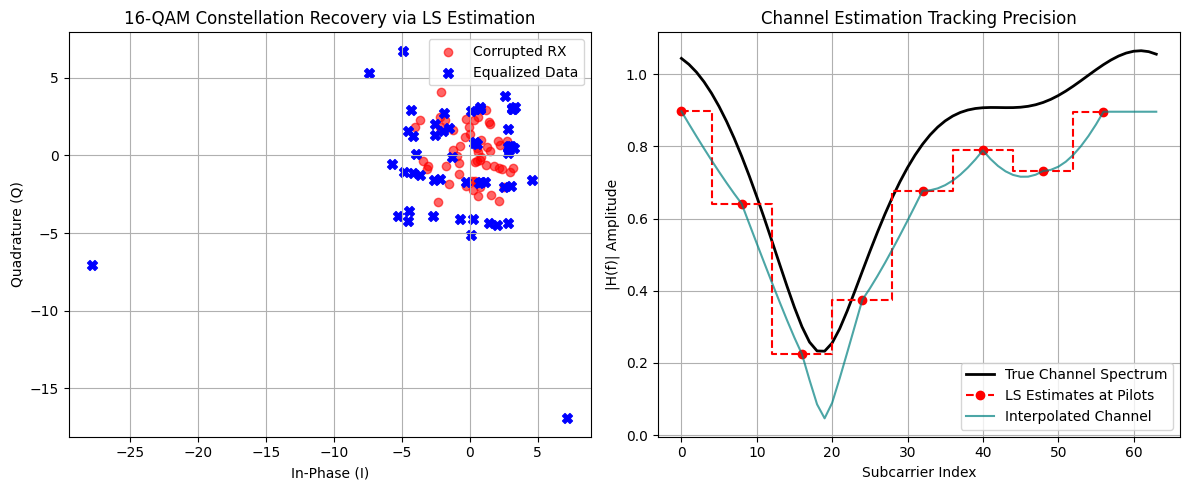

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. System Parameters ---
K = 64                          # Number of OFDM subcarriers
CP = K // 4                     # Cyclic Prefix length (16 samples)
P = 8                           # Number of pilot carriers
pilot_value = 3 + 3j            # Known pilot symbol
all_carriers = np.arange(K)

# Allocate pilot carriers evenly across the band
pilot_carriers = all_carriers[::K//P]
# Data carriers are the ones remaining
data_carriers = np.delete(all_carriers, pilot_carriers)

# 16-QAM Mapping Dictionary
qam_dict = {
    0: -3-3j, 1: -3-1j, 2: -3+3j, 3: -3+1j,
    4: -1-3j, 5: -1-1j, 6: -1+3j, 7: -1+1j,
    8:  3-3j, 9:  3-1j, 10: 3+3j, 11: 3+1j,
    12: 1-3j, 13: 1-1j, 14: 1+3j, 15: 1+1j
}

# --- 2. Transmitter Blocks ---
# Generate random data bits and map to 16-QAM
np.random.seed(42)
rand_data = np.random.randint(0, 16, len(data_carriers))
qam_data = np.array([qam_dict[b] for b in rand_data])

# Frame Assembly (Data + Pilots)
ofdm_frame = np.zeros(K, dtype=complex)
ofdm_frame[pilot_carriers] = pilot_value
ofdm_frame[data_carriers] = qam_data

# IFFT Modulation (Frequency to Time Domain Conversion)
time_domain_signal = np.fft.ifft(ofdm_frame)

# Cyclic Prefix Insertion (Guard Interval against ISI)
ofdm_tx_signal = np.concatenate([time_domain_signal[-CP:], time_domain_signal])

# --- 3. Multipath Channel Fading & Noise Injection ---
# Define a 3-tap frequency-selective Rayleigh fading channel response
channel_response = np.array([0.6 + 0.4j, 0.3 - 0.2j, 0.1 + 0.1j])
tx_faded = np.convolve(ofdm_tx_signal, channel_response, mode='same')

# Inject Additive White Gaussian Noise (AWGN)
SNR_dB = 25
signal_power = np.mean(np.abs(tx_faded)**2)
noise_power = signal_power / (10**(SNR_dB / 10))
noise = np.sqrt(noise_power/2) * (np.random.randn(len(tx_faded)) + 1j*np.random.randn(len(tx_faded)))
ofdm_rx_signal = tx_faded + noise

# --- 4. Receiver Blocks ---
# CP Removal (Discard Guard Interval)
rx_no_cp = ofdm_rx_signal[CP:CP+K]

# FFT Demodulation (Time back to Frequency Domain)
rx_frequency_domain = np.fft.fft(rx_no_cp)

# Least Squares (LS) Channel Estimation using known Pilots
H_est_pilots = rx_frequency_domain[pilot_carriers] / pilot_value
# Interpolate across all subcarriers to reconstruct the full channel estimate
H_estimated = np.interp(all_carriers, pilot_carriers, H_est_pilots)

# Zero-Forcing Frequency Domain Equalization
equalized_symbols = rx_frequency_domain / H_estimated

# --- 5. Performance Diagnostics Visualization ---
plt.figure(figsize=(12, 5))

# Plot 1: Received vs Equalized Constellation Diagrams
plt.subplot(1, 2, 1)
plt.scatter(rx_frequency_domain[data_carriers].real, rx_frequency_domain[data_carriers].imag, color='red', alpha=0.6, label='Corrupted RX')
plt.scatter(equalized_symbols[data_carriers].real, equalized_symbols[data_carriers].imag, color='blue', marker='X', s=50, label='Equalized Data')
plt.title('16-QAM Constellation Recovery via LS Estimation')
plt.xlabel('In-Phase (I)')
plt.ylabel('Quadrature (Q)')
plt.grid(True)
plt.legend()

# Plot 2: Frequency Response Estimation Matching Accuracy
plt.subplot(1, 2, 2)
H_actual = np.fft.fft(channel_response, K)
plt.plot(all_carriers, np.abs(H_actual), label='True Channel Spectrum', color='black', lw=2)
plt.step(pilot_carriers, np.abs(H_est_pilots), where='mid', label='LS Estimates at Pilots', color='red', linestyle='--', marker='o')
plt.plot(all_carriers, np.abs(H_estimated), label='Interpolated Channel', color='teal', alpha=0.7)
plt.title('Channel Estimation Tracking Precision')
plt.xlabel('Subcarrier Index')
plt.ylabel('|H(f)| Amplitude')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig('ofdm_transceiver_performance.png', dpi=300)
plt.show()